## FloPy for exporting model data

This notebook covers shapefile, raster, and VTK exporting capabilities within FloPy 

In [27]:
import flopy
import numpy as np
import pandas as pd
from pathlib import Path

shp_ws = Path("./lv_shapefiles")
vtk_ws = Path("./lv_vtk")

shp_ws.mkdir(exist_ok=True)
vtk_ws.mkdir(exist_ok=True)

## Shapefile exporting

In this example we'll explore the different ways to export shapefiles from model input and output data

### We'll be working with a simplified example version of the Lucerne Valley Model
![lv_model.png](./lv_model.png)

Load and run the simulation

In [28]:
sim_ws = Path("../../data/lvhm_simple")
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_ws)
sim.run_simulation()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package sto...
    loading package ic...
    loading package evt...
    loading package rch...
    loading package ghb...
    loading package hfb...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package lv_simple...
FloPy is using the following executable to run the model: ..\..\.pixi\envs\default\Scripts\mf6.exe
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                     VERSION 6.8.0+8680167.dirty 09/02/2026

   MODFLOW 6 compiled Sep 02 2026 20:02:10 with Intel(R) Fortran Intel(R) 64
  Compiler Classic for applications running on Intel(R) 64, Version 2021.12.0
                             Build 20240222_000000

This software has been approved for release by the U.S. Geological 
Survey (US

(True, [])

Get the model object and a copy of the modelgrid object

In [29]:
gwf = sim.get_model()
modelgrid = gwf.modelgrid

Check if the modelgrid has been projected in space

In [30]:
modelgrid

xll:500528.115; yll:3805502.63; rotation:0.0; units:meters; lenuni:2

In [31]:
print(modelgrid.crs)

None


In [32]:
# set CRS to UTM ZONE 11 N : epsg, 26911
epsg = 26911
modelgrid.set_coord_info(crs=f"EPSG:{epsg}")
modelgrid

xll:500528.115; yll:3805502.63; rotation:0.0; crs:EPSG:26911; units:meters; lenuni:2

#### Get a geodataframe of the modelgrid using `to_geodataframe()`

In [33]:
mgdf = modelgrid.to_geodataframe()
mgdf.head()

,geometry,node,row,col,active
0,"POLYGON ((500528.115 3822502.63, 500528.115 38...",1,1,1,0
1,"POLYGON ((501028.115 3822502.63, 501028.115 38...",2,1,2,0
2,"POLYGON ((501528.115 3822502.63, 501528.115 38...",3,1,3,0
3,"POLYGON ((502028.115 3822502.63, 502028.115 38...",4,1,4,0
4,"POLYGON ((502528.115 3822502.63, 502528.115 38...",5,1,5,0


plot only the active cells in the geodataframe

<Axes: >

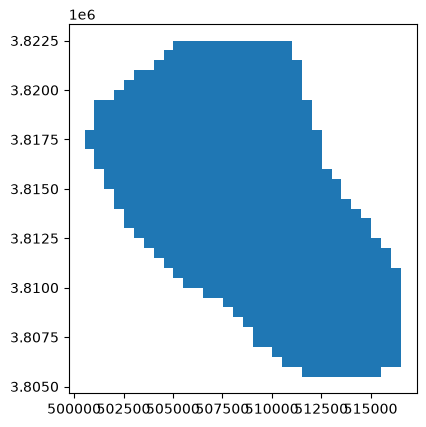

In [34]:
tmp = mgdf[mgdf["active"] == 1]
tmp.plot()

Add additional data from the modelgrid to the geodataframe

In [36]:
mgdf["top"] = modelgrid.top.ravel()

for i in range(modelgrid.nlay):
    mgdf[f"idomain_{i}"] = modelgrid.idomain[i].ravel()
    mgdf[f"botm_{i}"] = modelgrid.botm[i].ravel()

In [38]:
mgdf.head()

,geometry,node,row,col,active,top,idomain_0,botm_0,idomain_1,botm_1,idomain_2,botm_2
0,"POLYGON ((500528.115 3822502.63, 500528.115 38...",1,1,1,0,1091.0,0,1021.0,0,1001.0,0,911.0
1,"POLYGON ((501028.115 3822502.63, 501028.115 38...",2,1,2,0,1011.0,0,941.0,0,921.0,0,831.0
2,"POLYGON ((501528.115 3822502.63, 501528.115 38...",3,1,3,0,997.0,0,927.0,0,907.0,0,817.0
3,"POLYGON ((502028.115 3822502.63, 502028.115 38...",4,1,4,0,1150.0,0,1080.0,0,1060.0,0,970.0
4,"POLYGON ((502528.115 3822502.63, 502528.115 38...",5,1,5,0,1029.0,0,959.0,0,939.0,0,849.0


Export only the active extent of the model to shapefile

In [40]:
# live code


### Exporting data from MODFLOW Package data objects

Data can be exported from the different modflow package data objects (e.g. Array data and list data) using the `to_geodataframe()` method

#### Array data

In [42]:
hk = gwf.npf.k
hk

Layer_1{internal}
(array([[5. , 5. , 5. , ..., 1.3, 1.3, 1.3],
       [5. , 5. , 5. , ..., 1.3, 1.3, 1.3],
       [5. , 5. , 5. , ..., 1.3, 1.3, 1.3],
       ...,
       [0.1, 0.1, 0.1, ..., 0.2, 0.2, 0.2],
       [0.1, 0.1, 0.1, ..., 0.2, 0.2, 0.2],
       [0.1, 0.1, 0.1, ..., 0.2, 0.2, 0.2]], shape=(34, 32)))
Layer_2{internal}
(array([[0.1 , 0.1 , 0.1 , ..., 0.01, 0.01, 0.01],
       [0.1 , 0.1 , 0.1 , ..., 0.01, 0.01, 0.01],
       [0.1 , 0.1 , 0.1 , ..., 0.01, 0.01, 0.01],
       ...,
       [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
       [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
       [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01]], shape=(34, 32)))
Layer_3{internal}
(array([[38. , 38. , 38. , ..., 16. , 16. , 16. ],
       [38. , 38. , 38. , ..., 16. , 16. , 16. ],
       [38. , 38. , 38. , ..., 16. , 16. , 16. ],
       ...,
       [ 0.5,  0.5,  0.5, ...,  2. ,  2. ,  2. ],
       [ 0.5,  0.5,  0.5, ...,  2. ,  2. ,  2. ],
       [ 0.5,  0.5,  0.5, ...,  2. ,  2. ,  2. ]], shape=

In [43]:
dfhk = hk.to_geodataframe(full_grid=False)
dfhk.head()

,geometry,node,row,col,active,k_0,k_1,k_2
9,"POLYGON ((505028.115 3822502.63, 505028.115 38...",10,1,10,1,4.995400,0.099793,38.000000
10,"POLYGON ((505528.115 3822502.63, 505528.115 38...",11,1,11,1,4.774646,0.089859,38.000000
11,"POLYGON ((506028.115 3822502.63, 506028.115 38...",12,1,12,1,4.574568,0.094251,38.000000
12,"POLYGON ((506528.115 3822502.63, 506528.115 38...",13,1,13,1,4.287742,0.096023,37.027800
13,"POLYGON ((507028.115 3822502.63, 507028.115 38...",14,1,14,1,3.840106,0.085208,34.384163


In [44]:
# check the CRS
dfhk.crs

<Projected CRS: EPSG:26911>
Name: NAD83 / UTM zone 11N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 120°W and 114°W - onshore and offshore. Canada - Alberta; British Columbia; Northwest Territories; Nunavut. United States (USA) - California; Idaho; Nevada, Oregon; Washington.
- bounds: (-120.0, 30.88, -114.0, 83.5)
Coordinate Operation:
- name: UTM zone 11N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [45]:
# export to file
dfhk.to_file(shp_ws / "hk.shp")

#### List data (record type data)

In [46]:
wel = gwf.wel

In [48]:
spd = wel.stress_period_data
spd

{internal}
(    cellid_layer  cellid_row  cellid_column    q
0              2          24             31 -0.0
1              2          11             15 -0.0
2              2          11             14 -0.0
3              2          10             14 -0.0
4              2          10             14 -0.0
5              2           9             14 -0.0
6              2          13             17 -0.0
7              2          12             17 -0.0
8              2          12             16 -0.0
9              2          12             16 -0.0
10             2          13             14 -0.0
11             2          15             13 -0.0
12             2          16             13 -0.0
13             2          11             18 -0.0
14             2          13             18 -0.0
15             2          12             19 -0.0
16             2          12             19 -0.0
17             2          12             19 -0.0
18             2          14             16 -0.0
19      

In [51]:
weldf = spd.to_geodataframe(kper=18, full_grid=False,)
weldf.head()

,geometry,node,row,col,active,wel_q_2_18
302,"POLYGON ((507528.115 3818002.63, 507528.115 38...",303,10,15,1,-1547.083580
334,"POLYGON ((507528.115 3817502.63, 507528.115 38...",335,11,15,1,-457.003991
366,"POLYGON ((507528.115 3817002.63, 507528.115 38...",367,12,15,1,-1470.353760
367,"POLYGON ((508028.115 3817002.63, 508028.115 38...",368,12,16,1,-838.733399
370,"POLYGON ((509528.115 3817002.63, 509528.115 38...",371,12,19,1,-2493.852310


In [52]:
weldf.to_file(shp_ws / "wel_kper_18.shp")

### Exporting data from an entire package

We can also use `to_geodataframe()` to export all compatible data from a package

In [59]:
dis = gwf.dis
dis

package_name = dis
filename = lv_simple.dis
package_type = dis
model_or_simulation_package = model
model_name = lv_simple

Block options
--------------------
length_units
{internal}
('meters')

xorigin
{internal}
(500528.115)

yorigin
{internal}
(3805502.63)


Block dimensions
--------------------
nlay
{internal}
(3)

nrow
{internal}
(34)

ncol
{internal}
(32)


Block griddata
--------------------
delr
{internal}
(array([500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500.]))

delc
{internal}
(array([500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500.]))

top
{internal}
(array([[1091., 1011.,  997., ...,  963.,  965.,  964.],
       [ 997.,  963.,  968., ...,  949.,  

In [64]:
disdf = dis.to_geodataframe(shorten_attr=True)
disdf.head()

,geometry,node,row,col,active,top,botm_0,botm_1,botm_2,idomai_0,idomai_1,idomai_2
0,"POLYGON ((500528.115 3822502.63, 500528.115 38...",1,1,1,0,1091.0,1021.0,1001.0,911.0,0,0,0
1,"POLYGON ((501028.115 3822502.63, 501028.115 38...",2,1,2,0,1011.0,941.0,921.0,831.0,0,0,0
2,"POLYGON ((501528.115 3822502.63, 501528.115 38...",3,1,3,0,997.0,927.0,907.0,817.0,0,0,0
3,"POLYGON ((502028.115 3822502.63, 502028.115 38...",4,1,4,0,1150.0,1080.0,1060.0,970.0,0,0,0
4,"POLYGON ((502528.115 3822502.63, 502528.115 38...",5,1,5,0,1029.0,959.0,939.0,849.0,0,0,0


#### tack on additional package data from npf to the dis geodataframe

In [65]:
dis_npf_df = gwf.npf.to_geodataframe(gdf=disdf, shorten_attr=True)
dis_npf_df

,geometry,node,row,col,active,top,botm_0,botm_1,botm_2,idomai_0,...,idomai_2,icellt_0,icellt_1,icellt_2,k_0,k_1,k_2,k33_0,k33_1,k33_2
0,"POLYGON ((500528.115 3822502.63, 500528.115 38...",1,1,1,0,1091.0,1021.0,1001.0,911.0,0,...,0,1,1,1,5.0,0.10,38.0,0.50,0.010,3.8
1,"POLYGON ((501028.115 3822502.63, 501028.115 38...",2,1,2,0,1011.0,941.0,921.0,831.0,0,...,0,1,1,1,5.0,0.10,38.0,0.50,0.010,3.8
2,"POLYGON ((501528.115 3822502.63, 501528.115 38...",3,1,3,0,997.0,927.0,907.0,817.0,0,...,0,1,1,1,5.0,0.10,38.0,0.50,0.010,3.8
3,"POLYGON ((502028.115 3822502.63, 502028.115 38...",4,1,4,0,1150.0,1080.0,1060.0,970.0,0,...,0,1,1,1,5.0,0.10,38.0,0.50,0.010,3.8
4,"POLYGON ((502528.115 3822502.63, 502528.115 38...",5,1,5,0,1029.0,959.0,939.0,849.0,0,...,0,1,1,1,5.0,0.10,38.0,0.50,0.010,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083,"POLYGON ((514028.115 3806002.63, 514028.115 38...",1084,34,28,1,1059.0,989.0,969.0,879.0,1,...,1,1,1,1,0.2,0.01,2.0,0.02,0.001,0.2
1084,"POLYGON ((514528.115 3806002.63, 514528.115 38...",1085,34,29,1,1061.0,991.0,971.0,881.0,1,...,1,1,1,1,0.2,0.01,2.0,0.02,0.001,0.2
1085,"POLYGON ((515028.115 3806002.63, 515028.115 38...",1086,34,30,1,1058.0,988.0,968.0,878.0,1,...,1,1,1,1,0.2,0.01,2.0,0.02,0.001,0.2
1086,"POLYGON ((515528.115 3806002.63, 515528.115 38...",1087,34,31,0,1055.0,985.0,965.0,875.0,0,...,0,1,1,1,0.2,0.01,2.0,0.02,0.001,0.2


In [66]:
dis_npf_df.to_file(shp_ws / "dis_npf.shp")

#### Exporting HFB fault information

In [74]:
hfb = gwf.hfb
hfb

package_name = hfb
filename = lv_simple.hfb
package_type = hfb
model_or_simulation_package = model
model_name = lv_simple

Block dimensions
--------------------
maxhfb
{internal}
(57)


Block period
--------------------
stress_period_data
{internal}
(rec.array([((0, 26, 15), (0, 27, 15), 0.005),
           ((0, 26, 16), (0, 27, 16), 0.005),
           ((0, 26, 20), (0, 27, 20), 0.005),
           ((0, 26, 21), (0, 27, 21), 0.005),
           ((0, 26, 22), (0, 27, 22), 0.005),
           ((0, 26, 23), (0, 27, 23), 0.005),
           ((0, 27, 17), (0, 26, 17), 0.005),
           ((0, 27, 18), (0, 26, 18), 0.005),
           ((0, 27, 19), (0, 26, 19), 0.005),
           ((0, 27, 24), (0, 26, 24), 0.005),
           ((0, 27, 25), (0, 26, 25), 0.005),
           ((0, 27, 26), (0, 27, 25), 0.005),
           ((0, 27, 26), (0, 28, 26), 0.005),
           ((0, 27, 27), (0, 28, 27), 0.005),
           ((0, 28, 28), (0, 27, 28), 0.005),
           ((0, 28, 29), (0, 28, 30), 0.005),
           ((

In [78]:
hfbdf = hfb.to_geodataframe()
hfbdf.head()

,geometry,cellid1,cellid2,hydchr
0,"LINESTRING (508028.115 3809002.63, 508528.115 ...","(0, 26, 15)","(0, 27, 15)",0.005
1,"LINESTRING (508528.115 3809002.63, 509028.115 ...","(0, 26, 16)","(0, 27, 16)",0.005
2,"LINESTRING (510528.115 3809002.63, 511028.115 ...","(0, 26, 20)","(0, 27, 20)",0.005
3,"LINESTRING (511028.115 3809002.63, 511528.115 ...","(0, 26, 21)","(0, 27, 21)",0.005
4,"LINESTRING (511528.115 3809002.63, 512028.115 ...","(0, 26, 22)","(0, 27, 22)",0.005


In [80]:
# set crs and write to file
hfbdf.set_crs(epsg=epsg, inplace=True)
hfbdf.to_file(shp_ws / "hfbs.shp")

## Exporting shapefile data for an entire model

In [72]:
# live code
mdldf = gwf.to_geodataframe(shorten_attr=True)

In [81]:
mdldf.head()

,geometry,node,row,col,active,top,botm_0,botm_1,botm_2,idomai_0,...,rech20,bhea00,bhea10,bhea20,cond00,cond10,cond20,q00,q10,q20
0,"POLYGON ((500528.115 3822502.63, 500528.115 38...",1,1,1,0,1091.0,1021.0,1001.0,911.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"POLYGON ((501028.115 3822502.63, 501028.115 38...",2,1,2,0,1011.0,941.0,921.0,831.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"POLYGON ((501528.115 3822502.63, 501528.115 38...",3,1,3,0,997.0,927.0,907.0,817.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"POLYGON ((502028.115 3822502.63, 502028.115 38...",4,1,4,0,1150.0,1080.0,1060.0,970.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"POLYGON ((502528.115 3822502.63, 502528.115 38...",5,1,5,0,1029.0,959.0,939.0,849.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
mdldf = mdldf[mdldf["active"] > 0]
mdldf.to_file(shp_ws / "lvhm_model.shp")